## Case Study Assignement (word for word copy)
You are an employee of the fictitious company “202”, which sells several individual parts to engine manufacturers. The engine manufacturers supply the automobile brands “OEM1” and “OEM2”. The marketing department asks you to determine the market share for each part that the company produces compared to the competition. For advertising-technical reasons you are to determine also, in how many engines parts of “202” are installed. It is planned to advertise with the slogan: “In every xth engine there are parts from 202”. Furthermore, the high quality of the parts is to be advertised. Therefore, you are to determine the relative defect frequency of all parts in comparison to the competition. For the second part of your analysis, consider only engines that were installed in vehicles of the car brand “OEM1”. The time range in which the parts considered in the analysis were produced should be freely selectable.
## Main Case Study Task's (categorized in 4 points)
* 1. What is the market share of our company202 parts vs the competition?
* 2. Compare the defect frequency of our parts vs the competition for OEM 1 cars
* 3. How many Engines have parts from our company build in?
* 4. Create a Dashboard visualization

## The Plan is to gain an understanding of ...
* what kind of data and how much data we have?
* how this data is related?
* what role does our company 202 play in that data?
* what data is important for our case study?

## The Data selection strategy
* perfoming manual lookups into the files
* find out how much data we deal with
* how the data is formated
* gain understanding about what the columns mean and how they are correlated, by manually looking at the files and column names
* get an idea about what data could/would be important for the analysis
* importing the files
* identify relevant files through code
* visualize and document findings properly for better understating about how the relevant files are interesting in our case study

## Data structure
* The data is structured in 6 folders.

```
data/
├── Einzelteil/
├── Fahrzeug/
├── Geodaten/
├── Komponente/
├── Logistikverzug/
└── Zulassungen/
```
For language consistency we will refer to these folders and files in english.

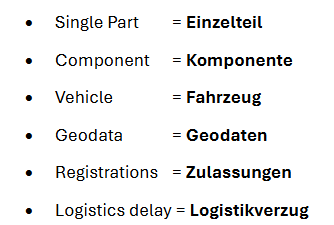

First about single parts also refered as parts from here on.

#### We performed a manual lookup and these were our findings:
* lookups done with ```less <filename>``` in Git bash because the files have a big file size (100MB+/file)

**Parts Lookup**:
* There are a mix of txt and csv files. Some of the txt files are formatted terribly
* Looking at a better formated file, we can see following columns"
"";"X1";"ID_T04";"Herstellernummer";"Werksnummer";"Fehlerhaft";"Fehlerhaft_Datum";"Fehlerhaft_Fahrleistung";"Produktionsdatum_Origin_01011970";"origin"
* The part ID (for example: "4-204-2042-23") together with the other columns gives an idea on how the id is structured.
* The first number stands for the part type, in this case part type 4
* The second number stands for the Tier-2 manufacturer number, here I can also find the manufacturer number 202 which seems to be us
* the third number stands for the Tier-2 plant number. A manufacturer can have multiple plants
* the final number seems to be a number that got added that makes the id unique
* Other than that we get to know if a certain part is faulty and when it was produced, tho the date is in a weird format using default time 01.01.1970 + offset
* In total there are 38 part types, part type 1-40. For some reason T28,T29 seems to be missing

**Components Lookup**:
* There are 2 file compositions
* Bestandteile_Komponente files shows the parts id's that build this component
* Komponente files show similar informations as the part files just with components
* We see which manufacturer made it, in which plant, at which date and if its faulty
* This time the manufactuere number and plant numbers start with 1. Probably because they are considered a T1 supplier
* The Component id (for example: "K1BE1-101-1011-11")is also interesting to look at because it also contains a lot of information actually
* the first part stands for the component type
* the second part stands for the manufacturer number
* the third part stands for the plant number 
* the last part stands probably again for a number that makes this id unique

**Car Lookup**:
* From the file names there seems to be 2 OEM manufacturers who produce each 2 type of cars
* Bestandteile Fahrzeuge contains 4 component id's that make up the car with a car id.
* Looking through multiple files it gives more information about the component files
* K references the component. There seems to be components from K1-K7, from the car file column names we can find out what each K represents
* K1 - Engine, K2 - Seats, K3 - Transmission, K4-K7 - Body. I was wondering why the body uses multiple K Numbers. After more lookup it became clear that each Car model type uses a specific body
* Going from the assumption that Everything are German abreviations we could interpret the abbreviations as following:
* BE=Benzin (petrol), DI=Diesel, ST=Stoff (fabric), LE=Leder (leather), SG=Schaltgetriebe (manual), AG=Automatikgetriebe (automatic).
* The other type of file is the Fahrzeuge OEM files. They say the manufacturing number, plant number of the OEM and some faulty analysis columns etc.

**Geodata Lookup**
* seems less useful for this case study, it describes where the plants of each manufacturer are located at

**Logistikverzug Lookup**
* The component K7 is a duplicate from the components folder and the delay shows informaton about the id, if its faulty or not and when it arrived at the oem.

**Zulassungen**
* it shows the German "Zulassungen" of all cars and where/when they are registered
* also doesnt seem important for this case study


### What data to check out
* From the question we can say that we produce parts for engines
* it is not guaranteed and should be checked to be safe
* What parts do we produce and what components are made out of our parts
* The component and part files seems most important. AS they also contain a column if its faulty they can be usefull for faulty analysis later on aswell
* The case analysis wants us to focus on the parts and not the components. Komponente files and the faulty rates of components are not needed here then. So we will only need the Bestandteile_Komponente files
* The case study want us to be able to differenciate between supplieng the oem1 and oem2 manufacturers. 
* We will need Bestandteile_Fahrzeuge_OEMX_Typxx files aswell to make that disticting
* Due to the structure and the use of ids and how they are used as a relational reference to other tables this whole data is like a relational database.

## Explorative Data Analysis Plan
* import and analyse part, component and oem files
* to reduce the import time and efforts I did filter the part files manually, to not needing to import 38 part files


* by using CONTOL+F we manually searched the 38 files by the manufacturing number "-202-" or "202"
* We found that only T01-T05 contain parts from manufacturer 202

## Importing revelant part files and tidy up data and datatypes


In [44]:
import io
from pathlib import Path
import pandas as pd

# Set path, filenames, field and row seperator
DATA = Path("data/Einzelteil")

FILES = {
    "t01": ("Einzelteil_T01.txt", b" | | ", b" "),
    "t02": ("Einzelteil_T02.txt", b"  ", b"\t"),
    "t03": ("Einzelteil_T03.txt", b"|", b"\x0b"),
    "t04": ("Einzelteil_T04.csv", b";", b"\n"),
    "t05": ("Einzelteil_T05.csv", b",", b"\n"),
}

def load(key: str) -> pd.DataFrame:
    filename, field_sep, row_sep = FILES[key]
    
    # Replacing field- and row- seperators in memory
    raw = (DATA / filename).read_bytes().replace(field_sep, b"\x01").replace(row_sep, b"\n")
    
    # Importing memory data in the dataframe
    df = pd.read_csv(io.BytesIO(raw), sep="\x01", na_values=["NA"], dtype=str)
    
    # Combine same columns (.x, .y)
    for col in set(c.removesuffix(".x").removesuffix(".y") for c in df.columns):
        # Only do it if these columns exist
        if col + ".x" in df.columns and col + ".y" in df.columns:
            # Combine columns
            df[col] = df[col + ".x"].combine_first(df[col + ".y"])

    # Standartize id and time columns
    part = key.upper()
    df["Part_ID"] = df.get(f"ID_{part}", df.get("Part_ID"))

    
    if "Produktionsdatum" not in df.columns and "Produktionsdatum_Origin_01011970" in df.columns:
        
        # Calculating productiondate if it is not there
        df["Produktionsdatum"] = pd.to_datetime("1970-01-01") + pd.to_timedelta(
            df["Produktionsdatum_Origin_01011970"].astype(float), unit="D"
        )

    # Convert datatypes
    df["Produktionsdatum"] = pd.to_datetime(df["Produktionsdatum"])
    df["Fehlerhaft_Datum"] = pd.to_datetime(df["Fehlerhaft_Datum"])
    df["Fehlerhaft_Fahrleistung"] = df["Fehlerhaft_Fahrleistung"].str.replace(",", ".", regex=False).astype(float)
    
    int_cols = ["Herstellernummer", "Werksnummer", "Fehlerhaft"]
    df[int_cols] = df[int_cols].astype("Int64")

    # Columns to keep
    columns = [
        "Part_ID", 
        "Herstellernummer", 
        "Werksnummer", 
        "Produktionsdatum", 
        "Fehlerhaft", 
        "Fehlerhaft_Datum", 
        "Fehlerhaft_Fahrleistung"
    ]

    return df[columns].reset_index(drop=True)

#### Loading the data and putting them in a list

In [45]:
part_names = ["t01", "t02", "t03", "t04", "t05"]
part_files = []
for part in part_names:
    part_files.append(load(part))

#### displaying the data


In [47]:
for part in part_files:
    display(part.head(5))

,Part_ID,Herstellernummer,Werksnummer,Produktionsdatum,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,1-201-2011-247,201,2011,2008-11-07,0,NaT,0.0
1,1-201-2011-429,201,2011,2008-11-07,0,NaT,0.0
2,1-201-2011-363,201,2011,2008-11-07,1,2009-09-30,12983.0
3,1-201-2011-30,201,2011,2008-11-07,0,NaT,0.0
4,1-201-2011-72,201,2011,2008-11-07,1,2009-09-30,12983.0


,Part_ID,Herstellernummer,Werksnummer,Produktionsdatum,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,2-201-2011-239,201,2011,2008-11-07,1,2010-04-09,38354.158904
1,2-201-2011-304,201,2011,2008-11-07,0,NaT,0.000000
2,2-201-2011-125,201,2011,2008-11-07,1,2010-04-09,38354.158904
3,2-201-2011-55,201,2011,2008-11-07,0,NaT,0.000000
4,2-201-2011-133,201,2011,2008-11-07,0,NaT,0.000000


,Part_ID,Herstellernummer,Werksnummer,Produktionsdatum,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,3-202-2023-249,202,2023,2008-11-07,0,NaT,0.0
1,3-202-2022-8,202,2022,2008-11-07,0,NaT,0.0
2,3-202-2023-192,202,2023,2008-11-07,0,NaT,0.0
3,3-202-2023-16,202,2023,2008-11-07,0,NaT,0.0
4,3-202-2023-258,202,2023,2008-11-07,0,NaT,0.0


,Part_ID,Herstellernummer,Werksnummer,Produktionsdatum,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,4-204-2043-113,204,2043,2008-11-07,0,NaT,0.0
1,4-202-2023-18,202,2023,2008-11-07,0,NaT,0.0
2,4-204-2043-98,204,2043,2008-11-07,0,NaT,0.0
3,4-202-2023-51,202,2023,2008-11-07,0,NaT,0.0
4,4-204-2043-169,204,2043,2008-11-07,0,NaT,0.0


,Part_ID,Herstellernummer,Werksnummer,Produktionsdatum,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
0,5-201-2012-82,201,2012,2008-11-07,1,2010-07-10,43163.430137
1,5-201-2012-172,201,2012,2008-11-07,0,NaT,0.000000
2,5-201-2012-23,201,2012,2008-11-07,0,NaT,0.000000
3,5-201-2012-47,201,2012,2008-11-07,1,2010-07-10,43163.430137
4,5-201-2012-101,201,2012,2008-11-07,0,NaT,0.000000


#### Data validation
* We can do an initial check if the data is valid or not
* Checking if the numbers of the Part_ID lines up with 